In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt

from msi.gaussian_likelihood.dense_emulator import DenseEmulator

from msi.utils import input_output, plotting, mcmc
from msfm.utils import prior, parameters

23-07-04 10:36:14    scales.py INF   Setting up healpy to run on 256 CPUs 


# network predictions

In [3]:
base_dir = "/pscratch/sd/a/athomsen/run_files/v3"
# base_dir = "/Users/arne/data/DESY3/models/v3/"

In [4]:
# # clustering only
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"
# n_steps = 50000
# params = ["Om", "s8", "bg", "n_bg"]

In [5]:
# # clustering only, with and without survey systematics
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"

# n_steps = 50000

# param_labels = ["Om", "s8", "bg", "n_bg"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

# # without survey systematics
# out_dir = os.path.join(base_dir, model_dir)
# preds_file = os.path.join(out_dir, f"preds_{n_steps}_no_survey_systematics.h5")

# with h5py.File(preds_file, "r") as f:
#     # fiducial
#     no_survey_systematics_fidu_vali_preds = f["fiducial/vali/pred"][:]
    
# print(no_survey_systematics_fidu_vali_preds.shape)


In [6]:
# lensing only
model_dir = "2023-05-29_09-55-49_resnet_vanilla"
n_steps = 50000
params = ["Om", "s8", "Aia", "n_Aia"]

In [7]:
# # combined probes
# model_dir = "2023-05-30_10-56-53_resnet_vanilla"
# n_steps = 10000
# params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

In [8]:
fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = input_output.load_preds(base_dir, model_dir, n_steps)

out_dir = os.path.join(base_dir, model_dir)
label = f"{n_steps}_gaussian_likelihood"

23-07-04 10:36:14 input_output INF   Array shapes:
 
23-07-04 10:36:14 input_output INF   fidu_train_preds =   (750, 4) 
23-07-04 10:36:14 input_output INF   fidu_vali_preds =    (50, 4) 
23-07-04 10:36:14 input_output INF   grid_preds =         (2499, 16, 4) 
23-07-04 10:36:14 input_output INF   grid_cosmos =        (2499, 4) 
23-07-04 10:36:14 input_output INF   grid_sobol =         (2499, 4) 


### observation

In [9]:
obs_pred = np.median(fidu_vali_preds, axis=0)

# Gaussian likelihood

### Covariance

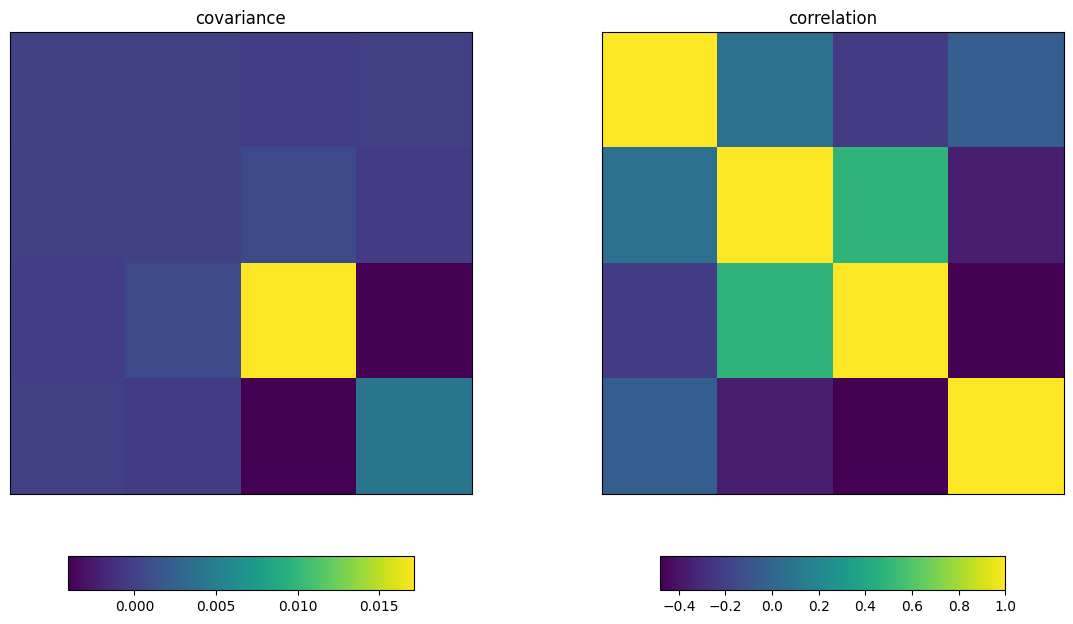

In [10]:
fid_cov = np.cov(fidu_vali_preds, rowvar=False)
fid_corr = np.corrcoef(fidu_vali_preds, rowvar=False)

fig, ax = plt.subplots(figsize=(14,8), ncols=2)

# covariance
im = ax[0].imshow(fid_cov)
ax[0].set(title="covariance")
ax[0].set_xticks([])
ax[0].set_yticks([])

fig.colorbar(im, ax=ax[0], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

# correlation
im = ax[1].imshow(fid_corr)
ax[1].set(title="correlation")
ax[1].set_xticks([])
ax[1].set_yticks([])

fig.colorbar(im, ax=ax[1], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

### prepare the training set

In [11]:
# spread the validation set evenly over the whole Sobol sequence in parameter space
split_index = -3

y_train = np.concatenate(grid_preds[:,:split_index,:], axis=0)
x_train = np.repeat(grid_cosmos, y_train.shape[0]//grid_cosmos.shape[0], axis=0)
print(y_train.shape)
print(x_train.shape)

y_vali = np.concatenate(grid_preds[:,split_index:,:], axis=0)
x_vali = np.repeat(grid_cosmos, y_vali.shape[0]//grid_cosmos.shape[0], axis=0)
print(x_vali.shape)
print(y_vali.shape)

(32487, 4)
(32487, 4)
(7497, 4)
(7497, 4)


### dense emulator network

In [12]:
emu = DenseEmulator(
    x_train.shape[-1], 
    y_train.shape[-1], 
    n_units=1024, 
    n_layers=4, 
    dropout_rate=0.2
)

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 4)]               0         
                                                                 
 tf.math.subtract (TFOpLambd  (None, 4)                0         
 a)                                                              
                                                                 
 tf.math.truediv (TFOpLambda  (None, 4)                0         
 )                                                               
                                                                 
 dense (Dense)               (None, 1024)              5120      
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 1024)              104960

In [13]:
history = emu.fit(
    x_train, 
    y_train, 
    validation_data=(x_vali, y_vali), 
    batch_size=2499, 
    epochs=1000, 
    early_stopping_callback=True, 
    learning_rate_callback=True
)

23-07-04 10:36:16 dense_emulat INF   Preprocessing scalers have been successfully fit 


epoch:  20%|██        | 205/1000 [00:19<01:13, 10.87it/s, loss=0.0302, val_loss=0.0385, lr=7.81e-6] 

Restoring model weights from the end of the best epoch: 106.


epoch:  21%|██        | 206/1000 [00:19<01:11, 11.04it/s, loss=0.0307, val_loss=0.0386, lr=7.81e-6]

Epoch 206: early stopping


epoch:  21%|██        | 206/1000 [00:19<01:14, 10.61it/s, loss=0.0307, val_loss=0.0386, lr=7.81e-6]


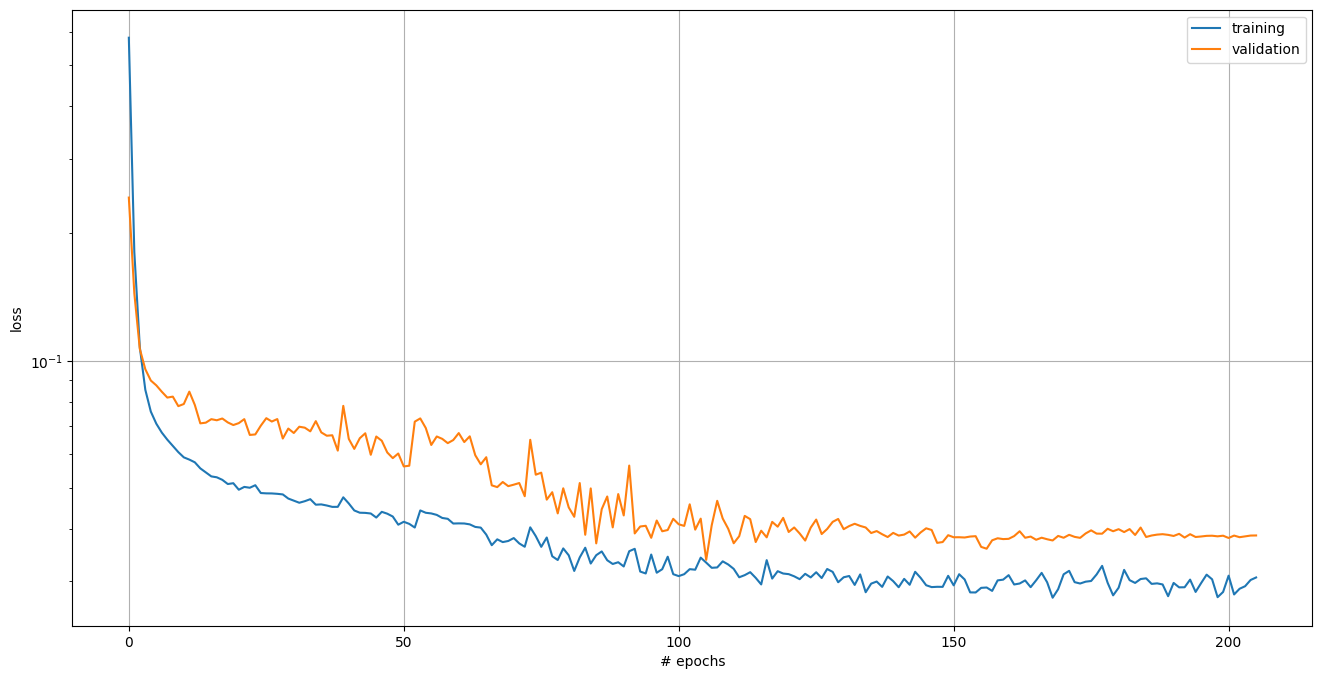

In [14]:
# plot
fig, ax = plt.subplots(figsize=(16,8))

ax.plot(history.history["loss"], label="training")
ax.plot(history.history["val_loss"], label="validation")

ax.legend()
ax.set(xlabel="# epochs", ylabel="loss", yscale="log")
ax.grid(True)

# MCMC

In [15]:
tf_cholesky = tf.linalg.cholesky(tf.cast(fid_cov, dtype=tf.float32))
tf_pred = tf.cast(obs_pred, dtype=tf.float32)

def log_likelihood(X): 
    # X = emu.scale_forward_x(X)
    normal = tfp.distributions.MultivariateNormalTriL(
        loc=emu(X), 
        scale_tril=tf_cholesky,
    )

    # evaluate the normal distribution
    log_prob = normal.log_prob(tf_pred)
    
    # enforce the prior
    log_prob = prior.log_posterior(X, log_prob, params=params, conf=None)

    return log_prob

In [16]:
chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=out_dir,
    label=label,
)

23-07-04 10:36:36      mcmc.py INF   Initial values in prior: True 


100%|██████████| 1000/1000 [01:19<00:00, 12.58it/s]


# plot

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

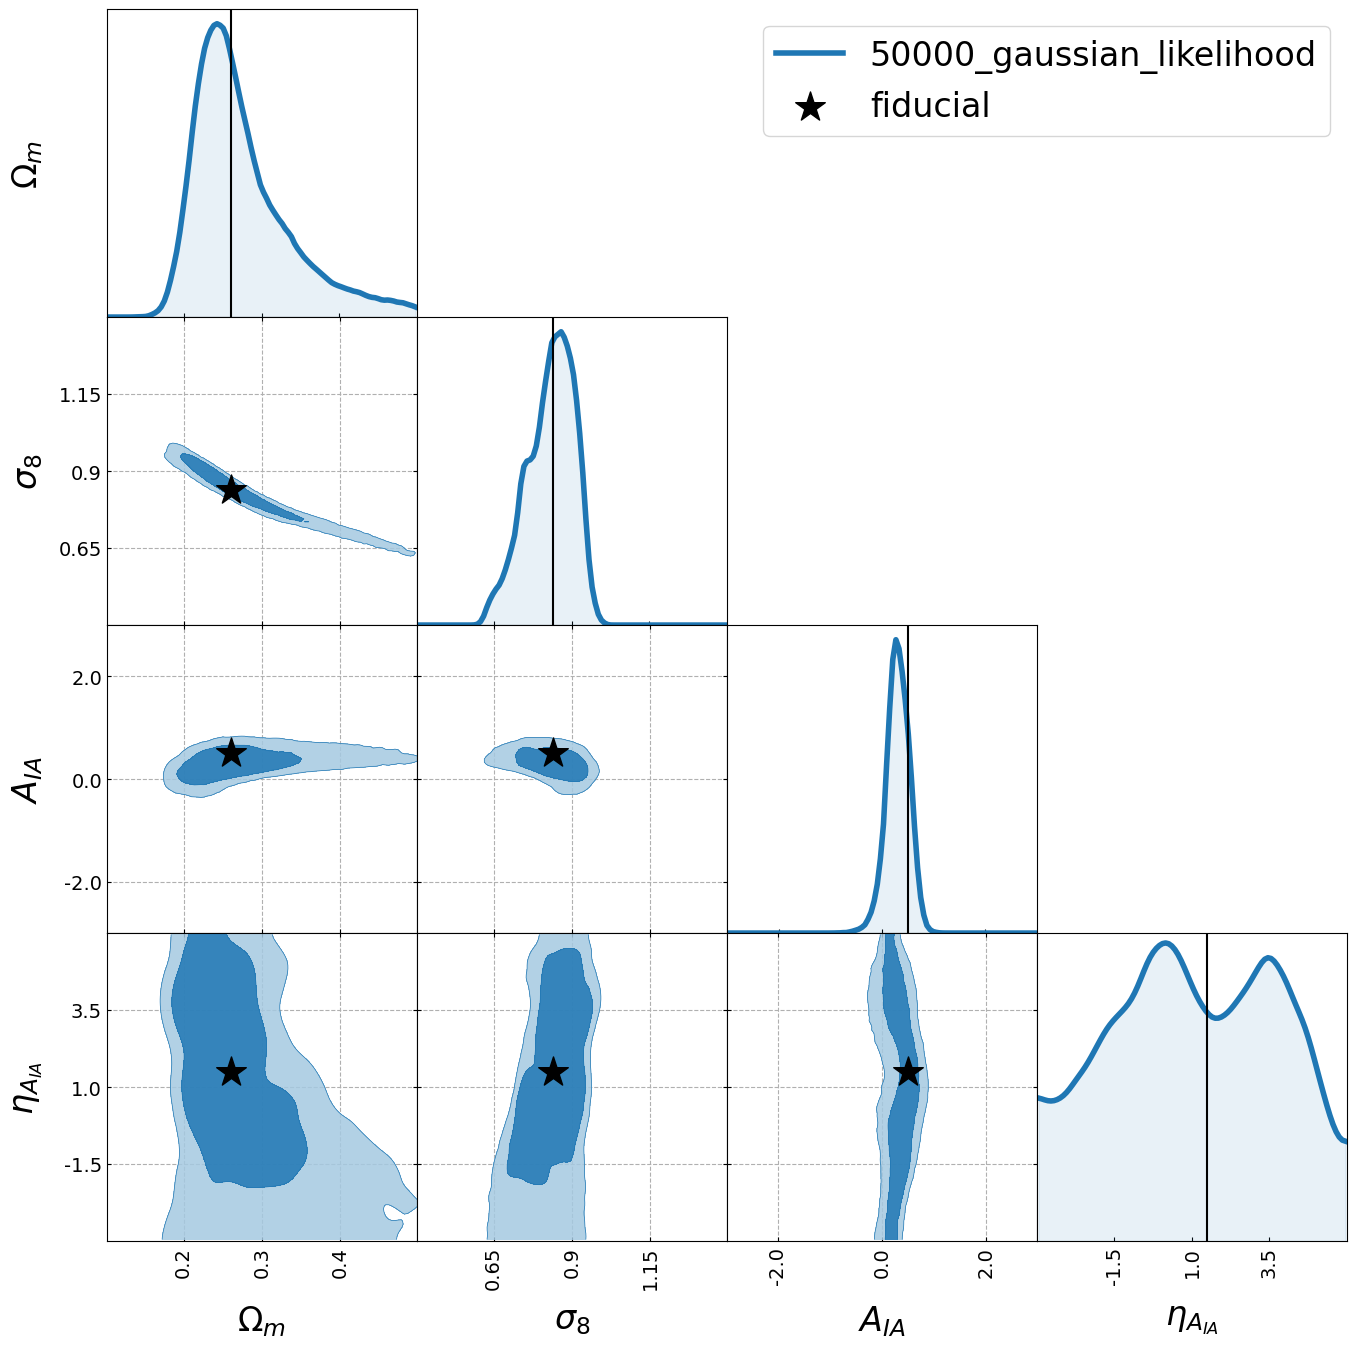

In [19]:
plotting.plot_chain(
    chain, 
    params, 
    out_dir=out_dir, 
    label=label,
)